In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict
from scipy.stats import mannwhitneyu
from scipy.stats import wilcoxon

import scienceplots

In [2]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = True

In [3]:
N_TRIALS = 80
T_INIT = 300
DT = 0.1
DT_RECORD = 10
N_NEURONS = 400

def load_data(folder):
    data = {}
    for trial in range(N_TRIALS):
        data[trial] = {}
        
        for file in os.listdir(folder):
            file_name = os.path.join(folder, file)
            
            if f"_{trial}_initial_weights.csv" in file:
                loaded_data = np.genfromtxt(file_name, delimiter=',', names=True, dtype=None, encoding='utf-8')
                N = loaded_data['post'].max()+1
                W = np.zeros((N, N), dtype=float)
                for pre, post, w in loaded_data:
                    W[pre, post] = w
                data[trial]['ws_init'] = W
                data[trial]['ws_init_list'] = loaded_data
                
            if f"_{trial}_final_weights.csv" in file:
                loaded_data = np.genfromtxt(file_name, delimiter=',', names=True, dtype=None, encoding='utf-8')
                N = loaded_data['post'].max()+1
                W = np.zeros((N, N), dtype=float)
                for pre, post, w in loaded_data:
                    W[pre, post] = w
                data[trial]['ws_final'] = W
                data[trial]['ws_final_list'] = loaded_data
                
            if f"_{trial}_neuron_ids" in file:
                with open(file_name, "r") as f:
                    neuron_ids = json.load(f)
                    data[trial]['ids'] = neuron_ids
                    
            if f"_{trial}_results.csv" in file:
                with open(file_name, "r") as f:
                    results = np.loadtxt(f)
                    data[trial]['s_acc'] = np.mean(results[:50])
                    data[trial]['e_acc'] = np.mean(results[-50:])
                    
    return data

def mann_whitney_report(x, y, alternative="two-sided", alpha=0.05):
    """
    Perform Mann–Whitney U test and print a formatted statistical report.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    n1 = len(x)
    n2 = len(y)

    # Descriptive statistics
    median_x = np.median(x)
    median_y = np.median(y)

    iqr_x = np.percentile(x, 75) - np.percentile(x, 25)
    iqr_y = np.percentile(y, 75) - np.percentile(y, 25)

    # Test
    res = mannwhitneyu(x, y, alternative=alternative)
    U = res.statistic
    p = res.pvalue

    # Effect sizes
    rank_biserial = 1 - (2 * U) / (n1 * n2)
    prob_superiority = U / (n1 * n2)

    # Print report
    print("Mann–Whitney U Test Report")
    print("-" * 40)
    print(f"Sample sizes: n1 = {n1}, n2 = {n2}")
    print()
    print("Descriptive statistics:")
    print(f"  Group 1: median = {median_x:.4f}, IQR = {iqr_x:.4f}")
    print(f"  Group 2: median = {median_y:.4f}, IQR = {iqr_y:.4f}")
    print()
    print("Test results:")
    print(f"  U statistic = {U:.4f}")
    print(f"  p-value     = {p}")
    print(f"  Rank-biserial correlation (effect size) = {rank_biserial:.4f}")
    print(f"  Probability of superiority              = {prob_superiority:.4f}")
    print()
    
    if p < alpha:
        print(f"Result: Significant difference (p < {alpha})")
    else:
        print(f"Result: No significant difference (p ≥ {alpha})")
        
        
        
def wilcoxon_signed_rank_report(x, y, alternative="two-sided", alpha=0.05, bonferroni=None):
    """
    Perform Wilcoxon signed-rank test and print a formatted statistical report.
    
    Parameters
    ----------
    x, y : array-like
        Paired samples (same length).
    alternative : {"two-sided", "greater", "less"}
    alpha : float
        Significance level.
    bonferroni : int or None
        Number of comparisons for Bonferroni correction.
        If provided, alpha is adjusted as alpha / bonferroni.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) != len(y):
        raise ValueError("Paired samples must have the same length.")

    n = len(x)
    differences = x - y

    # Remove zero differences (Wilcoxon automatically ignores them,
    # but we remove them explicitly for effect size calculation clarity)
    non_zero_diff = differences[differences != 0]
    n_effective = len(non_zero_diff)

    # Descriptive statistics
    median_x = np.median(x)
    median_y = np.median(y)

    iqr_x = np.percentile(x, 75) - np.percentile(x, 25)
    iqr_y = np.percentile(y, 75) - np.percentile(y, 25)

    median_diff = np.median(non_zero_diff)

    # Test
    res = wilcoxon(x, y, alternative=alternative)
    W = res.statistic
    p = res.pvalue

    # Effect size (paired rank-biserial correlation)
    # r = 1 - (2W / (n*(n+1)/2))
    max_W = n_effective * (n_effective + 1) / 2
    rank_biserial = 1 - (2 * W) / max_W

    # Bonferroni correction
    if bonferroni is not None and bonferroni > 0:
        adjusted_alpha = alpha / bonferroni
        p_adjusted = min(p * bonferroni, 1.0)
    else:
        adjusted_alpha = alpha
        p_adjusted = p

    # Print report
    print("Wilcoxon Signed-Rank Test Report")
    print("-" * 45)
    print(f"Number of pairs: n = {n}")
    print(f"Non-zero differences used: {n_effective}")
    print()

    print("Descriptive statistics:")
    print(f"  Sample 1: median = {median_x:.4f}, IQR = {iqr_x:.4f}")
    print(f"  Sample 2: median = {median_y:.4f}, IQR = {iqr_y:.4f}")
    print(f"  Median difference (x - y) = {median_diff:.4f}")
    print()

    print("Test results:")
    print(f"  W statistic = {W:.4f}")
    print(f"  Raw p-value = {p}")
    
    if bonferroni is not None and bonferroni > 0:
        print(f"  Bonferroni-adjusted p-value = {p_adjusted}")
        print(f"  Adjusted alpha = {adjusted_alpha}")
    else:
        print(f"  Alpha = {alpha}")

    print(f"  Rank-biserial correlation (effect size) = {rank_biserial:.4f}")
    print()

    if p_adjusted < adjusted_alpha:
        print(f"Result: Significant difference (p < {adjusted_alpha})")
    else:
        print(f"Result: No significant difference (p ≥ {adjusted_alpha})")


In [4]:
folder_fb = '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/FB/02_23_22_49_LR_1_PW_04_HigherDeltaBCM_30_17_15_4'
folder_nfb = '/Users/juliuswuerzler/Desktop/Results_Thesis/NoFb'
data = {}
data_nfb = {}

data = load_data(folder_fb)
data_nfb = load_data(folder_nfb)

In [5]:
def collect_weights(data, n_trials, mask_fn=None):
    start, end = [], []
    for i in range(n_trials):
        mask = mask_fn(data[i]) if mask_fn else slice(None)
        start.append(data[i]['ws_init_list']['w'][mask])
        end.append(data[i]['ws_final_list']['w'][mask])
    return np.concatenate(start), np.concatenate(end)

def stim_mask(trial):
    stim_ids = trial['ids']['stimulation_ids']
    return np.isin(trial['ws_init_list']['pre'], stim_ids) | np.isin(trial['ws_init_list']['post'], stim_ids)

all_start_weights,      all_end_weights      = collect_weights(data, N_TRIALS)
stim_start_weights,     stim_end_weights     = collect_weights(data, N_TRIALS, stim_mask)
not_stim_start_weights, not_stim_end_weights = collect_weights(data, N_TRIALS, lambda t: ~stim_mask(t))
all_start_weights_nfb,      all_end_weights_nfb      = collect_weights(data_nfb, N_TRIALS)
stim_start_weights_nfb,     stim_end_weights_nfb     = collect_weights(data_nfb, N_TRIALS, stim_mask)
not_stim_start_weights_nfb, not_stim_end_weights_nfb = collect_weights(data_nfb, N_TRIALS, lambda t: ~stim_mask(t))

In [6]:
incoming_weights_per_neuron = np.zeros((N_TRIALS, N_NEURONS))
incoming_weights_per_neuron_nfb = np.zeros_like(incoming_weights_per_neuron)
incoming_weights_per_neuron_init = np.zeros_like(incoming_weights_per_neuron)
incoming_weights_per_neuron_init_nofb = np.zeros_like(incoming_weights_per_neuron)

SPARSITY_THRESHOLD = 0.02
sparsity = np.zeros(N_TRIALS)
sparsity_nfb = np.zeros_like(sparsity)
sparsity_stim = np.zeros_like(sparsity)
sparsity_nstim = np.zeros_like(sparsity)

for i in range(N_TRIALS):
    for n in range(N_NEURONS):
        incoming_weights_per_neuron[i,n] = data[i]['ws_final'][:, n].sum()
        incoming_weights_per_neuron_nfb[i,n] = data_nfb[i]['ws_final'][:, n].sum()
        
        incoming_weights_per_neuron_init[i,n] = data[i]['ws_init'][n, :].sum()
        incoming_weights_per_neuron_init_nofb[i,n] = data_nfb[i]['ws_init'][n, :].sum()
        
    sparsity[i] = (data[i]['ws_final_list']['w'] < SPARSITY_THRESHOLD).mean()
    sparsity_nfb[i] = (data_nfb[i]['ws_final_list']['w'] < SPARSITY_THRESHOLD).mean()
    
    stim_ids = data[i]['ids']['stimulation_ids']
    pre_mask = np.isin(data[i]['ws_init_list']['pre'], stim_ids)
    post_mask = np.isin(data[i]['ws_init_list']['post'], stim_ids)
    sparsity_stim[i] = (data[i]['ws_final_list']['w'][:][pre_mask | post_mask] < SPARSITY_THRESHOLD).mean()
    sparsity_nstim[i] = (data[i]['ws_final_list']['w'][:][~(pre_mask | post_mask)] < SPARSITY_THRESHOLD).mean()

In [7]:
def hist_with_edge(ax, data, bins, label, color, density):
    ax.hist(data, bins, alpha=0.25, label=label, color=color, density=density)
    ax.hist(data, bins, alpha=1, color=color, density=density, histtype='step', linewidth=1)

In [8]:
np.mean(incoming_weights_per_neuron)

np.float64(0.4470180015066707)

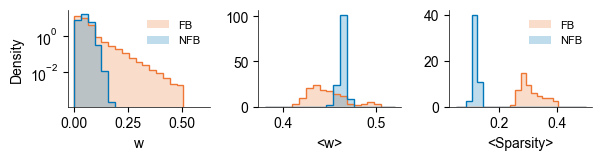

In [9]:
plt.style.use(['nature_d'])

fig, axs = plt.subplot_mosaic([["EndAll","EndMean", "Sparsity"]], sharey=False, width_ratios=[1,1,1])

# All weights
bins = np.linspace(0, 0.6, 20)
hist_with_edge(axs["EndAll"], all_end_weights, bins, "FB", ORANGE, True)
hist_with_edge(axs["EndAll"], all_end_weights_nfb, bins, "NFB", DARK_BLUE, True)
axs["EndAll"].set_yscale('log')
axs["EndAll"].set_ylabel("Density")
axs["EndAll"].set_xlabel("w")
axs["EndAll"].legend()

# mean weight per network
bins = np.linspace(0.38, 0.52, 20)
hist_with_edge(axs["EndMean"], incoming_weights_per_neuron.mean(axis=1), bins, "FB", ORANGE, True)
hist_with_edge(axs["EndMean"], incoming_weights_per_neuron_nfb.mean(axis=1), bins, "NFB", DARK_BLUE, True)
axs["EndMean"].set_xlabel("<w>")

# Sparsity
bins = np.linspace(0.05, 0.5, 25)
hist_with_edge(axs["Sparsity"], sparsity, bins, "FB", ORANGE, True)
# hist_with_edge(axs["Sparsity"], sparsity_stim, bins, "FB-Input", RED, True)
# hist_with_edge(axs["Sparsity"], sparsity_nstim, bins, "FB-Other", GRAY, True)
hist_with_edge(axs["Sparsity"], sparsity_nfb, bins, "NFB", DARK_BLUE, True)

# hist_with_edge(axs["Sparsity"], sparsity_nstim, bins, "FB:Rest", GRAY, True)
axs["Sparsity"].set_xlabel("<Sparsity>")
axs["Sparsity"].legend()

w, h = fig.get_size_inches()
fig.set_size_inches(w, 1.7)

fig.tight_layout()
if SAVE:
    fig.savefig("output/fig_2C_wChange.pdf", dpi=300)
    
plt.show()

In [10]:
wilcoxon_signed_rank_report(incoming_weights_per_neuron.mean(axis=1), incoming_weights_per_neuron_nfb.mean(axis=1), bonferroni=2)

Wilcoxon Signed-Rank Test Report
---------------------------------------------
Number of pairs: n = 80
Non-zero differences used: 80

Descriptive statistics:
  Sample 1: median = 0.4422, IQR = 0.0247
  Sample 2: median = 0.4638, IQR = 0.0036
  Median difference (x - y) = -0.0219

Test results:
  W statistic = 500.0000
  Raw p-value = 7.793653316144323e-08
  Bonferroni-adjusted p-value = 1.5587306632288645e-07
  Adjusted alpha = 0.025
  Rank-biserial correlation (effect size) = 0.6914

Result: Significant difference (p < 0.025)


In [11]:
wilcoxon_signed_rank_report(sparsity, sparsity_nfb, bonferroni=2)

Wilcoxon Signed-Rank Test Report
---------------------------------------------
Number of pairs: n = 80
Non-zero differences used: 80

Descriptive statistics:
  Sample 1: median = 0.2988, IQR = 0.0566
  Sample 2: median = 0.1210, IQR = 0.0064
  Median difference (x - y) = 0.1789

Test results:
  W statistic = 0.0000
  Raw p-value = 7.845373800597935e-15
  Bonferroni-adjusted p-value = 1.569074760119587e-14
  Adjusted alpha = 0.025
  Rank-biserial correlation (effect size) = 1.0000

Result: Significant difference (p < 0.025)


In [12]:
raise KeyboardInterrupt

KeyboardInterrupt: 

In [ ]:
mann_whitney_report(all_end_weights, all_end_weights_nfb)

Mann–Whitney U Test Report
----------------------------------------
Sample sizes: n1 = 320000, n2 = 320000

Descriptive statistics:
  Group 1: median = 0.0373, IQR = 0.0441
  Group 2: median = 0.0463, IQR = 0.0290

Test results:
  U statistic = 42551879635.0000
  p-value     = 0.0
  Rank-biserial correlation (effect size) = 0.1689
  Probability of superiority              = 0.4155

Result: Significant difference (p < 0.05)


In [ ]:
mann_whitney_report(incoming_weights_per_neuron.mean(axis=1), incoming_weights_per_neuron_nfb.mean(axis=1))

Mann–Whitney U Test Report
----------------------------------------
Sample sizes: n1 = 80, n2 = 80

Descriptive statistics:
  Group 1: median = 0.4422, IQR = 0.0247
  Group 2: median = 0.4638, IQR = 0.0036

Test results:
  U statistic = 1128.0000
  p-value     = 1.55786171390723e-12
  Rank-biserial correlation (effect size) = 0.6475
  Probability of superiority              = 0.1762

Result: Significant difference (p < 0.05)


In [ ]:
mann_whitney_report(sparsity, sparsity_nfb)

Mann–Whitney U Test Report
----------------------------------------
Sample sizes: n1 = 80, n2 = 80

Descriptive statistics:
  Group 1: median = 0.2988, IQR = 0.0566
  Group 2: median = 0.1210, IQR = 0.0064

Test results:
  U statistic = 6400.0000
  p-value     = 9.338017380644485e-28
  Rank-biserial correlation (effect size) = -1.0000
  Probability of superiority              = 1.0000

Result: Significant difference (p < 0.05)
